In [1]:
#Se importan todas las librerias necesarias o a utilizar.
import mne
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import signal # Nos permite realizar preprocesmaiento de la señal
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

## **Practica 3**
## **Randy Garcia Perez y David Garcia Marin**
## **Parte 2 (EEG)**

## **1. Obtencion y procesamiento de los datos.**

In [2]:
runs_validos = ['R04','R08','R12'] #Corresponden a "Task 2 (imagine opening and closing left or right fist)".
ruta_base = r"C:\UdeA\Semestre 20261\Bioseñales\files"
#ruta_base = r"C:/Users/david/OneDrive/Desktop/Archivos Bioseñales/EEG" 

In [3]:
# obtener solo carpetas
sujetos = [s for s in os.listdir(ruta_base) if os.path.isdir(os.path.join(ruta_base, s))] 

# Se ordenan
sujetos.sort()

# tomar solo 10
sujetos = sujetos[:10]

#Diccionario libre para llenar con los datos que se van a obtener
datos = {}

for sujeto in sujetos:
    
    ruta_sujeto = os.path.join(ruta_base, sujeto)
    
    raws = []
    
    for archivo in os.listdir(ruta_sujeto):
        #Aqui solo se toman los runs validos que se definieron con antelacion
        if archivo.endswith('.edf') and any(r in archivo for r in runs_validos):
            
            ruta_archivo = os.path.join(ruta_sujeto, archivo)
            raw = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
            raws.append(raw) 
    
    if raws:
        datos[sujeto] = mne.concatenate_raws(raws) #Aqui se unen todas las runs en una sola 

print("Sujetos usados:", list(datos.keys())) #Aqui se ve que sujetos se van a usar y que fueron obtenidos despues del filtro.

Sujetos usados: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']


In [4]:
#Codificando la informacion obtenida
mapping = {
    'T0': 'Rest',
    'T1': 'Imagine_Left',
    'T2': 'Imagine_Right'}

datos_epochs = {}


for sujeto in datos:
    
    raw = datos[sujeto]
    
    print("Procesando:", sujeto)
    
    #Se convierten las anotaciones en una matriz de eventos que MNE entienda
    events, event_id = mne.events_from_annotations(
        raw,
        event_id={'T0': 1, 'T1': 2, 'T2': 3}
    )
    
    #Se corta la señal en epocas se usa 1 segundo antes del marcador y 4 segundos después
    epochs = mne.Epochs(
        raw,
        events,
        event_id={'T1': 2, 'T2': 3}, 
        tmin=-1.0,
        tmax=4.0,
        baseline=None,          
        preload=True,
        verbose=False
    )
    
    # Se guardan los valores
    datos_epochs[sujeto] = {
        'T1': epochs['T1'],
        'T2': epochs['T2']
    }

Procesando: S001
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S002
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S003
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S004
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S005
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S006
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S007
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S008
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S009
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S010
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


In [5]:
conteo = []

for sujeto in datos_epochs:
    
    epochs_T1 = datos_epochs[sujeto]['T1']
    epochs_T2 = datos_epochs[sujeto]['T2']
    #Con esto cuento, cuantas epocas hay en cada estudio.
    conteo.append({
        'Sujeto': sujeto,
        'T1': len(epochs_T1),
        'T2': len(epochs_T2)
    })

df_conteo = pd.DataFrame(conteo)

print(df_conteo)

  Sujeto  T1  T2
0   S001  23  22
1   S002  23  22
2   S003  23  22
3   S004  23  22
4   S005  21  24
5   S006  24  21
6   S007  23  22
7   S008  22  23
8   S009  24  21
9   S010  24  21


## **2. Cálculo de la Amplitud Efectiva (RMS)**

In [6]:
#Se procede a calcular el valor rms de cada canal, esto me habla de la energia de cada canal.
def calcular_rms_por_canal(data):
    """
    data: (epocas, canales, muestras)
    retorna: (canales,)
    """
    rms_epoca = np.sqrt(np.mean(data**2, axis=2))   # (epocas, canales)
    rms_promedio = np.mean(rms_epoca, axis=0)       # (canales,)
    
    return rms_promedio

In [7]:
rms_T1 = {}
rms_T2 = {}

for sujeto in datos_epochs:
    
    epochs_T1 = datos_epochs[sujeto]['T1']
    epochs_T2 = datos_epochs[sujeto]['T2']
    
    data_T1 = epochs_T1.get_data()
    data_T2 = epochs_T2.get_data()
    
    # calcular RMS
    rms_T1[sujeto] = calcular_rms_por_canal(data_T1) 
    rms_T2[sujeto] = calcular_rms_por_canal(data_T2)

## **3. Construcción de la Base de Datos Poblacional**

In [8]:
canales = epochs_T1.ch_names #Se obtiene el nombre de los canales o electrodos usados

In [9]:
df_T1 = pd.DataFrame.from_dict(rms_T1, orient='index', columns=canales) 
df_T2 = pd.DataFrame.from_dict(rms_T2, orient='index', columns=canales) #Se guardan en DataFrames 

In [10]:
print(f" Tamaño de los datos del DataFrame de la prueba T1: {df_T1.shape}") #Se imprimen el tamaño
print(f" Tamaño de los datos del DataFrame de la prueba T2: {df_T2.shape}")

print("----------------------------------------------------------------------------------------")

print("DataFrame completo de la prueba T1")
print(df_T1) #Solo se imprime uno como para ver como esta organizado, el T2 sera igual.

 Tamaño de los datos del DataFrame de la prueba T1: (10, 64)
 Tamaño de los datos del DataFrame de la prueba T2: (10, 64)
----------------------------------------------------------------------------------------
DataFrame completo de la prueba T1
          Fc5.      Fc3.      Fc1.      Fcz.      Fc2.      Fc4.      Fc6.  \
S001  0.000048  0.000049  0.000050  0.000052  0.000049  0.000043  0.000039   
S002  0.000021  0.000020  0.000020  0.000021  0.000019  0.000018  0.000016   
S003  0.000069  0.000066  0.000062  0.000062  0.000060  0.000060  0.000061   
S004  0.000032  0.000028  0.000037  0.000026  0.000026  0.000026  0.000026   
S005  0.000065  0.000029  0.000045  0.000041  0.000033  0.000041  0.000041   
S006  0.000034  0.000022  0.000023  0.000021  0.000022  0.000021  0.000026   
S007  0.000038  0.000039  0.000039  0.000038  0.000039  0.000038  0.000036   
S008  0.000037  0.000037  0.000035  0.000033  0.000033  0.000033  0.000036   
S009  0.000105  0.000083  0.000076  0.000079  0.0000

## **4. Identificación de Canales Diferenciales mediante Análisis Estadístico**

In [ ]:
resultados = []
#En este apartado, se va a crear un DataFrame donde, se va a evaluar la normalidad de los datos para cada canal de T1 y T2.
for canal in df_T1.columns:
    
    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # --- Normalidad ---
    p_shapiro_1 = round(shapiro(grupo1)[1],5)
    
    if p_shapiro_1 > 0.05:
        significado_1 = "NORMALES"
    else:
        significado_1 = "NO_NORMALES"
    
    p_shapiro_2 = round(shapiro(grupo2)[1],5)

    if p_shapiro_2 > 0.05:
        significado_2 = "NORMALES"
    else:
        significado_2 = "NO_NORMALES"    
    
    #Se imprimen los resultados obtenidos
    resultados.append({
        'Canal': canal,
        'p_shapiro_T1': p_shapiro_1,
        'Resultado_s_T1': significado_1,
        'p_shapiro_T2': p_shapiro_2,
        'Resultado_s_T2': significado_2,
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Canal,p_shapiro_T1,Resultado_s_T1,p_shapiro_T2,Resultado_s_T2
0,Fc5.,0.01342,NO_NORMALES,0.00397,NO_NORMALES
1,Fc3.,0.01297,NO_NORMALES,0.00309,NO_NORMALES
2,Fc1.,0.00132,NO_NORMALES,0.00043,NO_NORMALES
3,Fcz.,0.00484,NO_NORMALES,0.00132,NO_NORMALES
4,Fc2.,0.06594,NORMALES,0.01622,NO_NORMALES
...,...,...,...,...,...
59,Po8.,0.00018,NO_NORMALES,0.00004,NO_NORMALES
60,O1..,0.00116,NO_NORMALES,0.00023,NO_NORMALES
61,Oz..,0.00082,NO_NORMALES,0.00016,NO_NORMALES
62,O2..,0.00012,NO_NORMALES,0.00005,NO_NORMALES


In [ ]:
#Ahora se van a filtrar los data frames para normales y no normales tanto para T1 como para T2
#Con el fin de obtener que canales usar para hacer las pruebas estadisticas mas adelante.

#CANALES NORMALES DE T1
Canales_Normales_T1 = df_resultados[df_resultados['Resultado_s_T1'] == "NORMALES" ]
Canales_Normales_T1= Canales_Normales_T1.drop(columns=['p_shapiro_T2','Resultado_s_T2']).reset_index()
Canales_Normales_T1= Canales_Normales_T1.drop(columns=['index'])
#-------------------------------------------------------------------------------------------

#CANALES NORMALES DE T2
Canales_Normales_T2 = df_resultados[df_resultados['Resultado_s_T2'] == "NORMALES" ]
Canales_Normales_T2= Canales_Normales_T2.drop(columns=['p_shapiro_T1','Resultado_s_T1']).reset_index()
Canales_Normales_T2= Canales_Normales_T2.drop(columns=['index'])
#----------------------------------------------------------------------------------------

#CANALES NO NORMALES DE T1
Canales_NO_Normales_T1 = df_resultados[df_resultados['Resultado_s_T1'] == "NO_NORMALES" ]
Canales_NO_Normales_T1= Canales_NO_Normales_T1.drop(columns=['p_shapiro_T2','Resultado_s_T2']).reset_index()
Canales_NO_Normales_T1= Canales_NO_Normales_T1.drop(columns=['index'])
#--------------------------------------------------------------------------------------------------

#CANALES NO NORMALES DE T2
Canales_NO_Normales_T2 = df_resultados[df_resultados['Resultado_s_T2'] == "NO_NORMALES" ]
Canales_NO_Normales_T2= Canales_NO_Normales_T2.drop(columns=['p_shapiro_T1','Resultado_s_T1']).reset_index()
Canales_NO_Normales_T2= Canales_NO_Normales_T2.drop(columns=['index'])

In [ ]:
#Se realizan la prueba de homocedasticidad y prueba t, a los valores que fueron normales.
resultados_1 = []

#Aqui se filtra cuales fueron los canales que son normales
canales_T1 = Canales_Normales_T1['Canal'].tolist()
canales_T2 = Canales_Normales_T2['Canal'].tolist()
df_T1_normales = df_T1[canales_T1]
df_T2_normales = df_T2[canales_T2]
# solo canales que existen en ambos
canales_comunes = df_T1_normales.columns.intersection(df_T2_normales.columns)

#Se proceden a aplicar las pruebas
for canal in canales_comunes:

    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # --- Levene ---
    p_levene = round(levene(grupo1, grupo2)[1], 5)
    
    if p_levene > 0.05:
        significado_3 = "HOMOCEDASTICO"
    else:
        significado_3 = "NO_HOMOCEDASTICO"
    
    #Solo se le hace prueba t a los canales que son Homocedasticos (Todos lo son)
    if  p_levene > 0.05:

        # --- t-test ---
        p_t = round(ttest_ind(grupo1, grupo2)[1], 5)
        
        resultado_t = "DIFERENCIA" if p_t <= 0.05 else "NO_DIFERENCIA"
    else:
        p_t = "NO_APLICA"    
        resultado_t = "NO_APLICA"    

    resultados_1.append({
        'Canal': canal,
        'p_levene': p_levene,
        'Resultado_l': significado_3,
        'p_ttest': p_t,
        'Resultado_t': resultado_t
    })

#Se imprimen los resultados
df_resultados1 = pd.DataFrame(resultados_1)

df_resultados1

,Canal,p_levene,Resultado_l,p_ttest,Resultado_t
0,C1..,0.87902,HOMOCEDASTICO,0.88471,NO_DIFERENCIA
1,Cz..,0.92859,HOMOCEDASTICO,0.95659,NO_DIFERENCIA
2,C2..,0.97704,HOMOCEDASTICO,0.94783,NO_DIFERENCIA
3,Cp1.,0.91522,HOMOCEDASTICO,0.91232,NO_DIFERENCIA
4,Cp2.,0.84704,HOMOCEDASTICO,0.91269,NO_DIFERENCIA
5,Cp4.,0.84492,HOMOCEDASTICO,0.94490,NO_DIFERENCIA
6,Fz..,0.94142,HOMOCEDASTICO,0.97929,NO_DIFERENCIA
7,P1..,0.86128,HOMOCEDASTICO,0.88552,NO_DIFERENCIA
8,Pz..,0.94720,HOMOCEDASTICO,0.94159,NO_DIFERENCIA
9,P2..,0.86220,HOMOCEDASTICO,0.95402,NO_DIFERENCIA


In [ ]:
#Se realizan la prueba de U de mann-whitney, a los valores que NO fueron normales.
resultados_2 = []

#Aqui se filtra cuales canales NO son normales.
canales_T1_no = Canales_NO_Normales_T1['Canal'].tolist()
canales_T2_no = Canales_NO_Normales_T2['Canal'].tolist()
df_T1_NOnormales = df_T1[canales_T1_no]
df_T2_NOnormales = df_T2[canales_T2_no]
# solo canales que existen en ambos
canales_comunes_1 = df_T1_NOnormales.columns.intersection(df_T2_NOnormales.columns)

for canal in canales_comunes_1:

    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # prueba U de Mann-Whitney
    stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')
    p = round(p, 5)
    
    resultado = "DIFERENCIA" if p <= 0.05 else "NO_DIFERENCIA"
    
    resultados_2.append({
        'Canal': canal,
        'p_mannwhitney': p,
        'Resultado': resultado
    })

#Se imprimen los resultados
df_resultados2 = pd.DataFrame(resultados_2)

df_resultados2

,Canal,p_mannwhitney,Resultado
0,Fc5.,0.96985,NO_DIFERENCIA
1,Fc3.,0.90972,NO_DIFERENCIA
2,Fc1.,0.85011,NO_DIFERENCIA
3,Fcz.,0.96985,NO_DIFERENCIA
4,Fc4.,1.00000,NO_DIFERENCIA
5,Fc6.,0.90972,NO_DIFERENCIA
6,C5..,1.00000,NO_DIFERENCIA
7,C3..,0.79134,NO_DIFERENCIA
8,C4..,0.96985,NO_DIFERENCIA
9,C6..,0.96985,NO_DIFERENCIA


In [ ]:
#Se desea hallar el canal mas significativo, para eso se busca cual tuvo menor valor p en la prueba t y en la de U de mann-whitney
Menor_Normales = df_resultados1["p_ttest"].min()
Canal_menor = df_resultados1[df_resultados1['p_ttest'] == Menor_Normales]['Canal']
print(Menor_Normales,Canal_menor)
print("------------------------------------------------------")
Menor__NONormales = df_resultados2["p_mannwhitney"].min()
Canal_menor_NO = df_resultados2[df_resultados2['p_mannwhitney'] == Menor__NONormales]['Canal']
print(Menor__NONormales,Canal_menor_NO)

#Se encontro que el canal con menor valor p es el "F8..", por ende este seria el mas significativo.


0.88471 0    C1..
Name: Canal, dtype: object
------------------------------------------------------
0.73373 29    F8..
Name: Canal, dtype: object


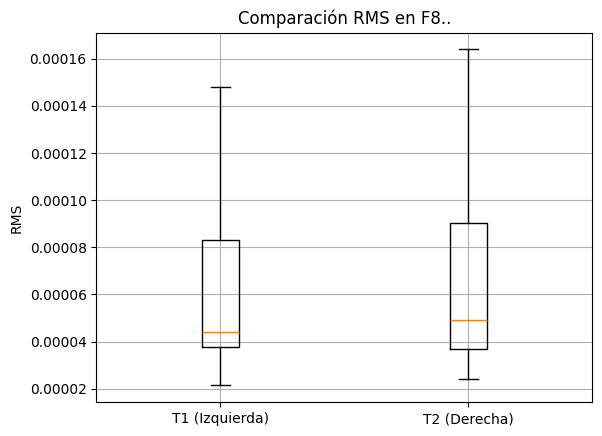

In [ ]:
#Se hace un boxlot de el canal F8.. en los grupos T1 y T2
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(
    [df_T1["F8.."], df_T2["F8.."]],
    tick_labels=['T1 (Izquierda)', 'T2 (Derecha)']
)

plt.title('Comparación RMS en F8..')
plt.ylabel('RMS')

plt.grid()
plt.show()

## **5. CONCLUSIONES**

Los resultados muestran que NO se encontraron diferencias estadisticamente significativas entre las condiciones de imagineria motora de mano izquierda (T1) y mano derecha (T2), incluso en los canales motores C3 y C4, donde fisiologicamente se esperaría observar una desincronización contralateral, ya que estos canales corresponden a las áreas de la corteza sensoriomotora que controlan las funciones motoras de los lados opuestos del cuerpo, durante las tareas de ejecución motora, como los movimientos voluntarios, estimulados e imaginarios, el hemisferio contralateral (C3 para los movimientos de la mano derecha y C4 para los movimientos de la mano izquierda) muestra patrones de desincronización (ERD) relacionados con los eventos, lo que indica la actividad neuronal asociada con la planificación y ejecución motoras, lo que refleja las diferencias hemisféricas en las distribuciones de energía del EEG [1]. No obstante, en nuestro caso no se evidencia una diferencia entre estos canales, aunque, esto puede parecer contradictorio con la teoría, hay varias razones que pueden explicar este resultado.

Por un lado, es posible que los datos no hayan sido procesados lo suficiente, como por ejemplo, una falta de filtrado en las bandas de interes como $\mu$ y $\beta$, donde puede hacer que el efecto de desincronización no sea visible. Ademas, puede el ruido muscular, movimiento o interferencias externas, que afectan bastante la señal EEG. Por otro lado, si no se trabajo con ventanas de tiempo bien alineadas al evento o si se uso una medida global como el RMS, es probable que se esten perdiendo cambios mas especificos en frecuencia. A esto se suma la variabilidad natural entre ensayos o sujetos, que puede ocultar diferencias reales.

Por ultimo, aunque el canal F8 presentó el menor valor p, su ubicacion frontal no está directamente relacionada con la corteza motora, y el boxplot muestra bastante solapamiento entre T1 y T2, lo que nos dice que no hay una separación clara entre condiciones. En conlusión, los resultados sugieren que, bajo este enfoque, no es posible diferenciar las tareas por medio de analisis y pruebas estadisticas.

# Referencias:

[1] Dong, M., Li, N., Anshuang, F., Rui, X., Shuang, Q., Qiang, X., Peng, Z., Lixin, Z., & Baikun, W. (2014). Time-frequency analysis of EEG signals evoked by voluntary, stimulated and imaginary motions. Transactions of Tianjin University, 20(3), 210–214. https://doi.org/10.1007/S12209-014-2180-3